# Milestone 1 — Data Report, EDA & Preprocessing

**Insurance Price Prediction** capstone. Target: `insurance_cost` (regression).

This notebook performs the data report, univariate/bivariate/multivariate EDA, and preprocessing/feature-engineering required by Milestone 1. All reusable logic lives in the `insurance` package so the production pipeline and this notebook stay in sync.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from insurance import config, data
from insurance.features import FeatureEngineer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
FIG = config.FIGURES_DIR

## 1. Data Report
Import the dataset, inspect shape/size, and review attribute info.

In [2]:
raw = data.load_raw()
print("Shape:", raw.shape)
print("Size :", raw.size)
raw.head()

Shape: (25000, 24)
Size : 600000


,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,0,Male,97,31.2,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,0,Male,212,34.2,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,0,Female,166,40.4,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,0,Female,109,22.9,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,1,Male,118,26.5,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  object 
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  object 
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  object 
 12  avg_glucose_level               

### Schema cleanup
The problem statement has typo columns (`regular_checkup_lasy_year`, `heart_decs_history`, `other_major_decs_history`) and a category typo (`Salried`). `clean_schema()` fixes these. `applicant_id` is a unique key with no predictive signal and is dropped during feature engineering.

In [4]:
df = data.load_clean()
data_dict = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
data_dict.to_csv(config.TABLES_DIR / "data_dictionary.csv")
data_dict

,dtype,missing,missing_pct,n_unique
applicant_id,int64,0,0.00,25000
years_of_insurance_with_us,int64,0,0.00,9
regular_checkup_last_year,int64,0,0.00,6
adventure_sports,int64,0,0.00,2
Occupation,object,0,0.00,3
visited_doctor_last_1_year,int64,0,0.00,12
cholesterol_level,object,0,0.00,5
daily_avg_steps,int64,0,0.00,4914
age,int64,0,0.00,59
heart_disease_history,int64,0,0.00,2


**Observation:** 25,000 rows × 24 columns, no duplicate applicant IDs. Only `bmi` (~4%) and `Year_last_admitted` (~47.5%) contain missing values. The high missingness in `Year_last_admitted` is meaningful (no prior admission) rather than random.

## 2. Missing Values

,missing,missing_pct
Year_last_admitted,11881,47.52
bmi,990,3.96


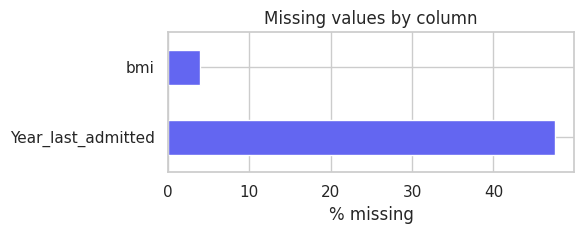

In [5]:
miss = data_dict[data_dict["missing"] > 0][["missing", "missing_pct"]].sort_values("missing", ascending=False)
display(miss)
ax = miss["missing_pct"].plot(kind="barh", color="#6366f1", figsize=(6, 2.5))
ax.set_xlabel("% missing"); ax.set_title("Missing values by column")
plt.tight_layout(); plt.savefig(FIG / "missing_values.png", dpi=120); plt.show()

## 3. Univariate Analysis
### Continuous features

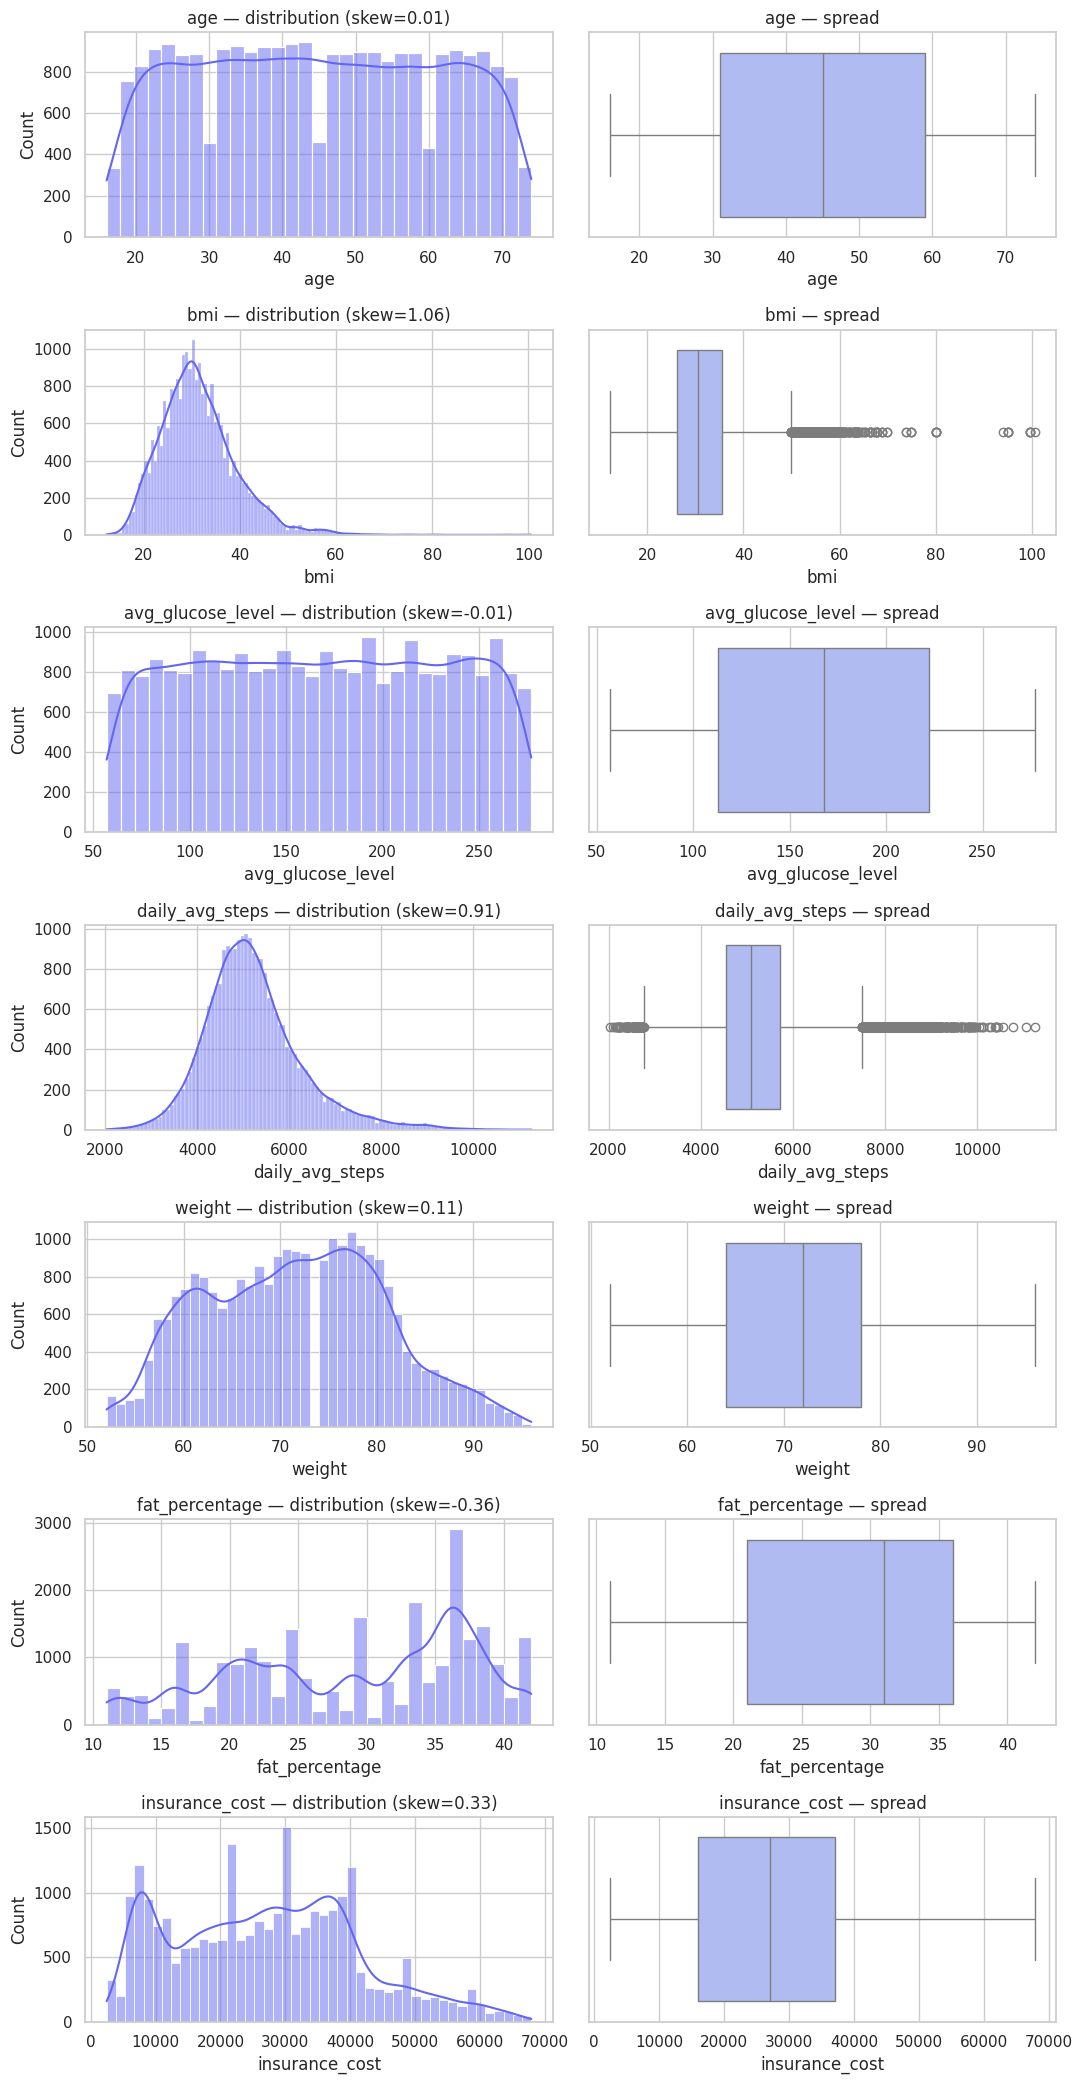

In [6]:
continuous = ["age", "bmi", "avg_glucose_level", "daily_avg_steps", "weight",
              "fat_percentage", "insurance_cost"]
fig, axes = plt.subplots(len(continuous), 2, figsize=(11, 3 * len(continuous)))
for i, col in enumerate(continuous):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="#6366f1")
    axes[i, 0].set_title(f"{col} — distribution (skew={df[col].skew():.2f})")
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="#a5b4fc")
    axes[i, 1].set_title(f"{col} — spread")
plt.tight_layout(); plt.savefig(FIG / "univariate_continuous.png", dpi=110); plt.show()

**Observation:** `insurance_cost` is mildly right-skewed (~0.33). `bmi`, `weight`, `avg_glucose_level`, and `daily_avg_steps` are roughly symmetric; `daily_avg_steps` and `bmi` show some outliers worth reviewing.

### Categorical features

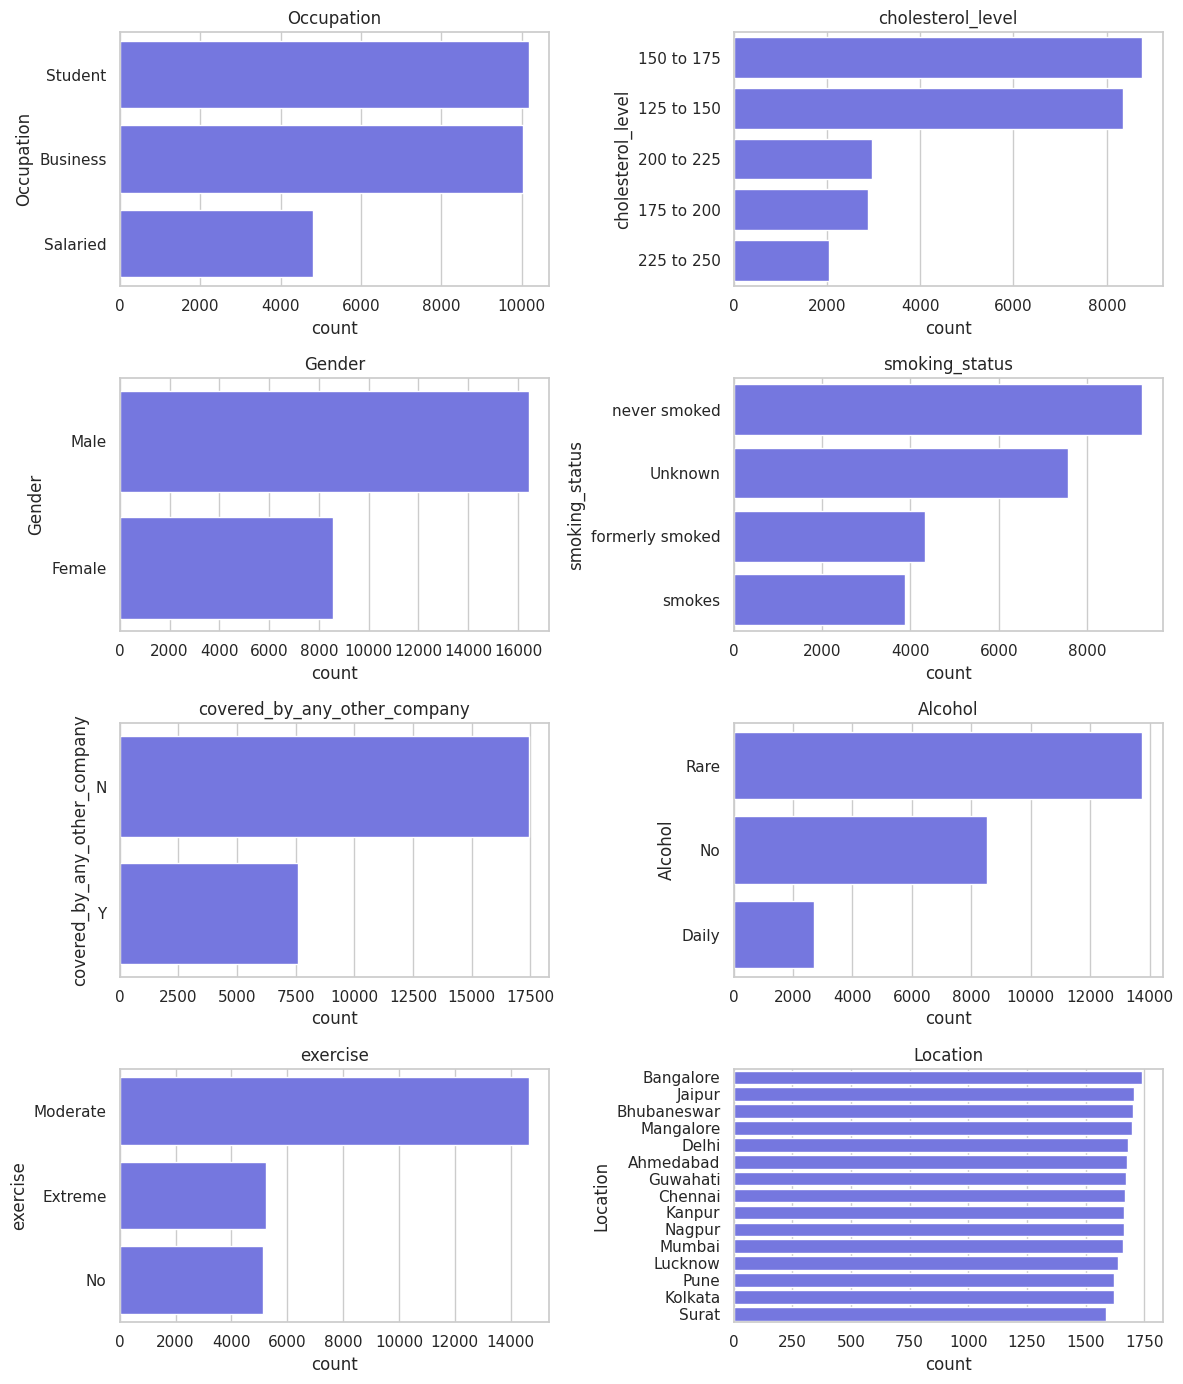

In [7]:
categorical = ["Occupation", "cholesterol_level", "Gender", "smoking_status",
               "covered_by_any_other_company", "Alcohol", "exercise", "Location"]
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for ax, col in zip(axes.ravel(), categorical):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#6366f1")
    ax.set_title(col)
plt.tight_layout(); plt.savefig(FIG / "univariate_categorical.png", dpi=110); plt.show()

**Observation:** `Occupation` is dominated by Student/Business (~40% each); Male applicants ~66%; ~30% have `Unknown` smoking status (kept as a valid category); Locations are fairly uniform across 15 cities.

## 4. Bivariate & Multivariate Analysis
### Correlation heatmap

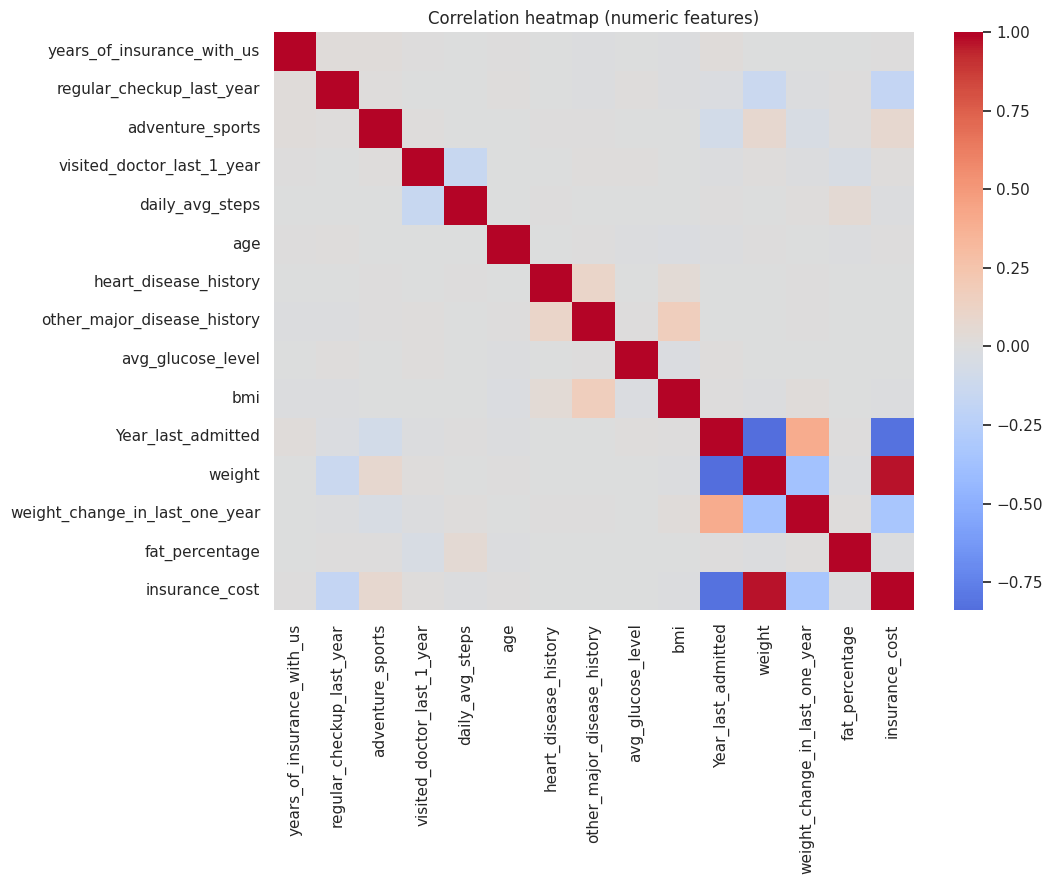

insurance_cost                    1.000000
weight                            0.970357
adventure_sports                  0.074561
visited_doctor_last_1_year        0.008890
age                               0.005195
years_of_insurance_with_us        0.001404
heart_disease_history            -0.000445
other_major_disease_history      -0.002268
avg_glucose_level                -0.005007
daily_avg_steps                  -0.006565
bmi                              -0.008231
fat_percentage                   -0.008486
regular_checkup_last_year        -0.174005
weight_change_in_last_one_year   -0.342710
Year_last_admitted               -0.824137
Name: insurance_cost, dtype: float64

In [8]:
num = df.select_dtypes(include=np.number).drop(columns=[config.ID_COL])
plt.figure(figsize=(11, 9))
sns.heatmap(num.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.savefig(FIG / "correlation_heatmap.png", dpi=120); plt.show()
num.corr()["insurance_cost"].sort_values(ascending=False)

**Observation:** `weight` has an unusually strong positive correlation with `insurance_cost` — it dominates the signal. This is flagged for a plausibility / leakage review before any real-world deployment (kept in the model but documented).

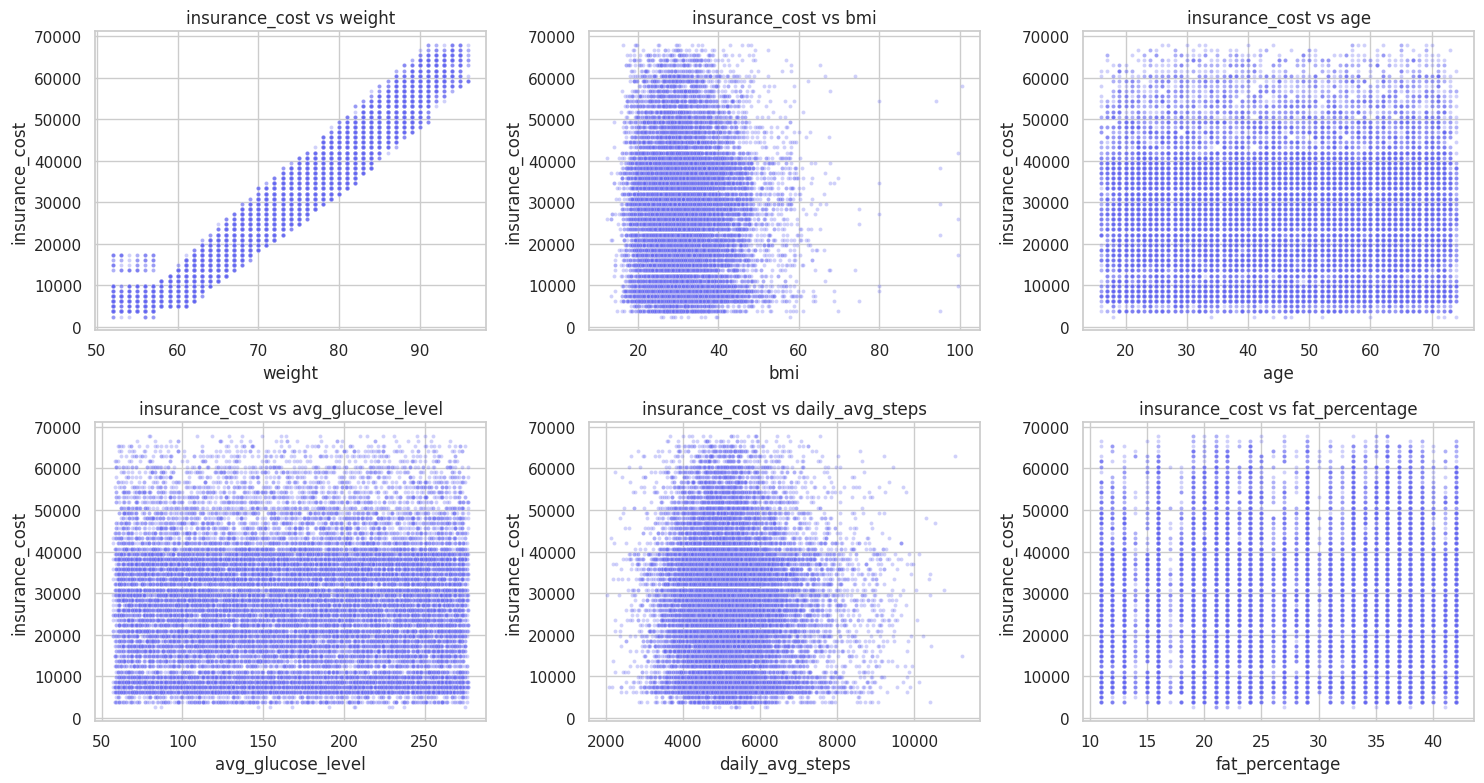

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["weight", "bmi", "age", "avg_glucose_level", "daily_avg_steps", "fat_percentage"]):
    sns.scatterplot(x=df[col], y=df["insurance_cost"], s=8, alpha=0.3, ax=ax, color="#6366f1")
    ax.set_title(f"insurance_cost vs {col}")
plt.tight_layout(); plt.savefig(FIG / "scatter_vs_target.png", dpi=110); plt.show()

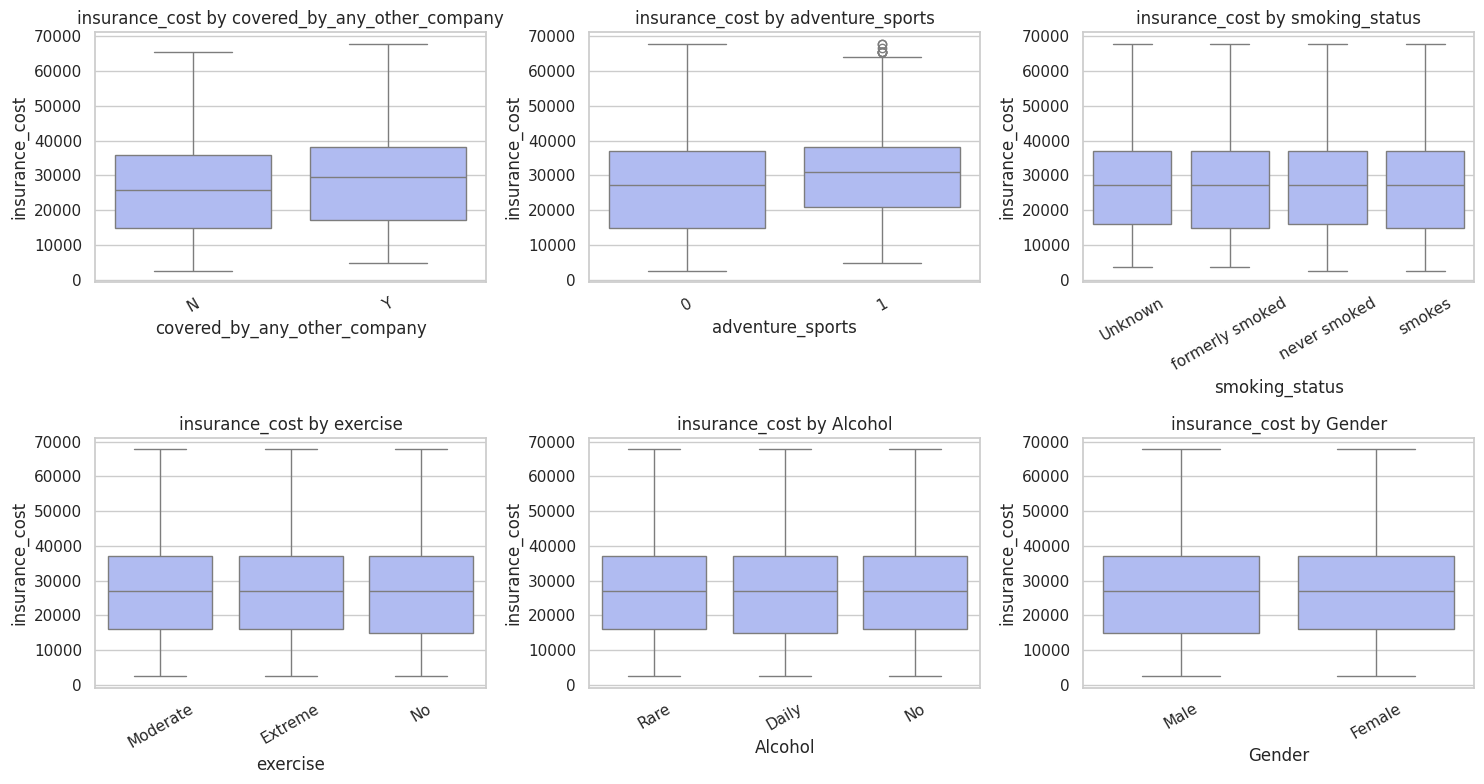

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["covered_by_any_other_company", "adventure_sports", "smoking_status", "exercise", "Alcohol", "Gender"]):
    sns.boxplot(x=df[col], y=df["insurance_cost"], ax=ax, color="#a5b4fc")
    ax.set_title(f"insurance_cost by {col}"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(FIG / "boxplots_by_category.png", dpi=110); plt.show()

**Observation:** `covered_by_any_other_company=Y` and `adventure_sports=1` show clearly higher median cost. Lifestyle factors (smoking, alcohol, exercise) have similar medians but can still matter through nonlinear interactions captured by tree models.

## 5. Outlier Review

In [11]:
def iqr_table(frame, cols):
    rows = []
    for c in cols:
        q1, q3 = frame[c].quantile([.25, .75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = ((frame[c] < lo) | (frame[c] > hi)).sum()
        rows.append([c, q1, q3, iqr, lo, hi, out, round(out / len(frame) * 100, 2)])
    return pd.DataFrame(rows, columns=["col", "q1", "q3", "iqr", "lower", "upper", "outliers", "pct"])

iqr_table(df, ["bmi", "weight", "avg_glucose_level", "daily_avg_steps", "fat_percentage", "insurance_cost"])

,col,q1,q3,iqr,lower,upper,outliers,pct
0,bmi,26.1,35.6,9.5,11.85,49.85,549,2.20
1,weight,64.0,78.0,14.0,43.00,99.00,0,0.00
2,avg_glucose_level,113.0,222.0,109.0,-50.50,385.50,0,0.00
3,daily_avg_steps,4543.0,5730.0,1187.0,2762.50,7510.50,952,3.81
4,fat_percentage,21.0,36.0,15.0,-1.50,58.50,0,0.00
5,insurance_cost,16042.0,37020.0,20978.0,-15425.00,68487.00,0,0.00


**Treatment:** target outliers are *retained* (high premiums can be valid and business-relevant). `bmi` is capped only at unrealistic extremes (12–60). `daily_avg_steps` outliers are mild and kept; tree models are robust to them.

## 6. Preprocessing & Feature Engineering

In [12]:
print("Duplicate rows:", df.duplicated().sum())
print("Dropping non-predictive id:", config.ID_COL)

fe = FeatureEngineer().fit(df.drop(columns=[config.TARGET]))
engineered = fe.transform(df.drop(columns=[config.TARGET]))
print("Engineered matrix shape:", engineered.shape)
engineered.head()

Duplicate rows: 0
Dropping non-predictive id: applicant_id
Engineered matrix shape: (25000, 28)


,years_of_insurance_with_us,regular_checkup_last_year,visited_doctor_last_1_year,daily_avg_steps,age,avg_glucose_level,bmi,weight,weight_change_in_last_one_year,fat_percentage,adventure_sports,heart_disease_history,other_major_disease_history,cholesterol_midpoint,years_since_last_admitted,was_admitted_before,any_major_disease_history,weight_bmi_interaction,steps_per_age,Occupation,Gender,smoking_status,Location,covered_by_any_other_company,Alcohol,exercise,age_band,bmi_category
0,3,1,2,4866,28,97,31.2,67,1,25,1,1,0,137.5,0.0,0,1,2090.4,173.785714,Salaried,Male,Unknown,Chennai,N,Rare,Moderate,0-29,Obese
1,0,0,4,6411,50,212,34.2,58,3,27,0,0,0,162.5,0.0,0,0,1983.6,128.220000,Student,Male,formerly smoked,Jaipur,N,Rare,Moderate,40-49,Obese
2,1,0,4,4509,68,166,40.4,73,0,32,0,0,0,212.5,0.0,0,0,2949.2,66.308824,Business,Female,formerly smoked,Jaipur,N,Daily,Extreme,60+,Obese
3,7,4,2,6214,51,109,22.9,71,3,37,0,0,0,187.5,0.0,0,0,1625.9,121.843137,Business,Female,Unknown,Chennai,Y,Rare,No,50-59,Normal
4,3,1,2,4938,44,118,26.5,74,0,34,0,0,1,162.5,14.0,1,1,1961.0,112.227273,Student,Male,never smoked,Bangalore,N,No,Extreme,40-49,Overweight


**Engineered features** (in `insurance.features.FeatureEngineer`):
- `age_band`, `bmi_category` — risk bucketing
- `cholesterol_midpoint` — numeric encoding of the cholesterol range
- `was_admitted_before`, `years_since_last_admitted` — derived from `Year_last_admitted` (missing = never admitted)
- `any_major_disease_history` — heart OR other disease
- `weight_bmi_interaction`, `steps_per_age` — interaction/ratio signals

**Missing-value strategy:** `bmi` imputed with the median by (`age_band`, `Gender`) and a global fallback; `Year_last_admitted` re-expressed as the two admission features above.

**Scaling:** numeric columns are standardized inside the production `ColumnTransformer` (`insurance.preprocess`), fit on the training fold only. Required for linear/regularized models, harmless for tree models.

## Milestone 1 Summary
The dataset is clean after schema fixes, with only two columns needing missing-value treatment. EDA shows `weight`, other-coverage, admission history, and preventive checkups as the strongest cost signals. The preprocessing + feature-engineering pipeline is now reusable for Milestone 2 modeling.